# Representatividad y sesgo

## Representatividad
Una muestra es **representativa** cuando refleja razonablemente las características de la población.

## Sesgo
El **sesgo** es un error sistemático. Ocurre cuando la muestra no representa bien a la población.

## Ejemplo de sesgo
Si para estudiar a todos los pasajeros del Titanic tomamos solo pasajeros de primera clase, la muestra no será representativa del total.

## Idea clave
No siempre más datos significa mejor análisis. Una muestra pequeña pero bien tomada puede ser mejor que una muestra grande y sesgada.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic = sns.load_dataset("titanic").dropna(subset=["fare", "age", "class"])
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
# Población real
print(titanic["class"].value_counts(normalize=True))

class
Third     0.497199
First     0.260504
Second    0.242297
Name: proportion, dtype: float64


# CREAMOS UNA MUESTRA SESGADA

In [4]:
muestra_sesgada = titanic[titanic["class"] == "First"]

# CREAMOS UNA MUESTRA ALEATORIA

In [5]:
muestra_aleatoria = titanic.sample(n=100, random_state=42)

# COMPARAMOS AMBAS MUESTRAS CON LA POBLACIÓN

In [6]:
print("Promedio fare población:", round(titanic["fare"].mean(), 2))
print("Promedio fare muestra sesgada:", round(muestra_sesgada["fare"].mean(), 2))
print("Promedio fare muestra aleatoria:", round(muestra_aleatoria["fare"].mean(), 2))

Promedio fare población: 34.69
Promedio fare muestra sesgada: 87.96
Promedio fare muestra aleatoria: 36.71


# GRAFICAMOS LOS VALORES

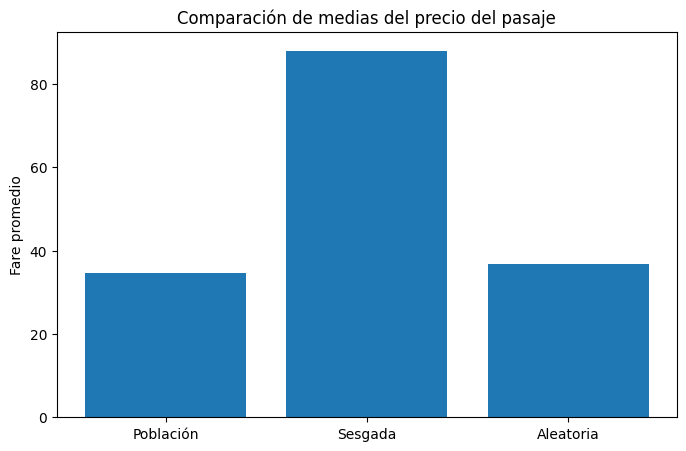

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(["Población", "Sesgada", "Aleatoria"], [
    titanic["fare"].mean(),
    muestra_sesgada["fare"].mean(),
    muestra_aleatoria["fare"].mean()
])
ax.set_title("Comparación de medias del precio del pasaje")
ax.set_ylabel("Fare promedio")
plt.show()